**Module 3: Data Practices and Responsible Modeling.** The provided code notebook presents an example of training a simple classifier (Decision Tree Model) on a small dataset (Palmer Penguins), looks at subgroup metrics, and gives an example of a datasheet. The codebook prompts students to consider tradeoffs and decisions made from preprocessing, model choice, and interpretation.  
We provide the code to create:

1. A Decision Tree model.
1. Post-hoc analysis.
1. A datasheet markdown.
1. The purpose of the code notebook is to provide students with a hands-on example of a human-centered data science problem and responsible modeling.  

This code book is used to help students:  

- Reflect on assumptions about neutrality, objectivity, and measurement.  
- Connect HCDS to ethical, societal, and policy considerations by looking at subgroup metrics vs larger classifier accuracy.  
- Understand the role of datasheets in helping others understand the data used to run a machine learning model.  

While this workbook utilizes a simple dataset like "Palmer Penguins," it serves as a foundation for students to consider the decisions, trade-offs, and impacts that machine learning has on complex human problems. For instance, the same analysis could be applied to a medical dataset to predict patient diagnoses based on health and demographic factors.
**The Mapping:**
- Target Variable: Instead of predicting a penguin species, we would be identifying a specific medical diagnosis.
- Input Features: Instead of physical penguin measurements, we would analyze human biometrics and health history.

Using a manageable dataset, allows students to focus on the underlying mechanics of bias, data imputation, and model selection before applying these critical concepts to high-stakes human data.


The code can be adapted as instructors see fit, including lengthening the example, creating more/different features, increasing the complexity of the model, and/or using your own dataset.

In [5]:
# Requirements: numpy, pandas, matplotlib, seaborn, scikit-learn
# Tested with Python 3.12, scikit-learn >=1.0

# Import packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import plot_tree

# create custom HCDS Lab palette
custom_palette = ['#1c5b49', '#a4dfce', '#15ad81', '#71cdb3', '#178868', '#adadad']

# create custom HCDS Lab color mapping
custom_cmap = LinearSegmentedColormap.from_list("white_to_green",["#ffffff", '#1c5b49'])

In [6]:
# Load dataset
df = sns.load_dataset("penguins")

In [7]:
# view a snapshot of the data set
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


**Consider:**
1. There are a lot of nulls in this data set, how should null values be handled?

2. What trade-offs are there with the decision you make?

3. How should you document and report the decision you made and the trade-offs and or bias this may lead to?


In [8]:

# Data cleaning and model training pipeline

# Drop missing values for sex
# Dropped to prevent introducing noise to the target variable
df["sex"].dropna(inplace=True)

# Create features
num_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
cat_features = ["sex"]


# Assign X and y
X = df[num_features + cat_features]
y = df["species"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocess and impute the null values (Mean Imputation)
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on the training data
X_train[num_features] = imputer.fit_transform(X_train[num_features])

# Transform the test data using means from the training data
X_test[num_features] = imputer.transform(X_test[num_features])

# 3. One-hot encode categorical variables
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Train model
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Print overall model accuracy
print("Overall Accuracy:", accuracy_score(y_test, y_pred))

Overall Accuracy: 0.9710144927536232


**Consider:**
In this code, the model is chosen for you. What information was used to select this model?

**Ask**
1. If this dataset were larger or more complex, what is another model we might use?
1. If this dataset were unlabelled, how would that change the model selection?
1. What trade-offs have been made by selecting Decision Tree as the model?

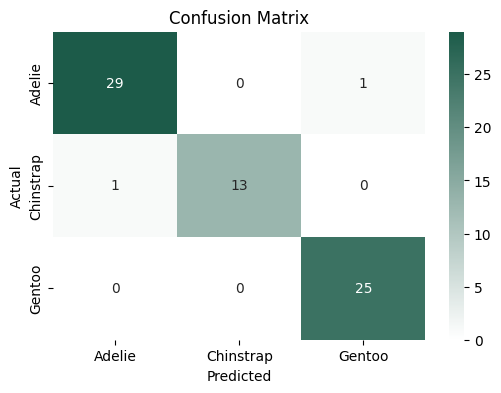

In [9]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# Plot
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=custom_cmap,
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [10]:
# look at classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        30
   Chinstrap       1.00      0.93      0.96        14
      Gentoo       0.96      1.00      0.98        25

    accuracy                           0.97        69
   macro avg       0.98      0.97      0.97        69
weighted avg       0.97      0.97      0.97        69



**Ask:**
What do the accuracy scores tell us about the classification model’s ability to predict species?

**Consider:**
If this were a dataset concerning human health, how would differences in accuracy impact our decision-making regarding the use of this model?

**The Scenario:** Imagine the three penguin species are now three different diseases, and you are specifically targeting Disease 2 (formerly Chinstrap).

1. What does a 100% precision score for Disease 2 tell you in a medical context?
1. What does a 93% recall score for Disease 2 tell you?
1. Given these metrics, would you select this model for a healthcare setting? Why or why not?


In [11]:
# Subgroup performance analysis - accuracy

# create test data frame
df_test = df.loc[X_test.index].copy()
df_test["y_true"] = y_test
df_test["y_pred"] = y_pred

# Sex subgroup performance analysis
for sex in df_test["sex"].unique():
    subset = df_test[df_test["sex"] == sex]
    acc = accuracy_score(subset["y_true"], subset["y_pred"])
    prec = precision_score(subset["y_true"], subset["y_pred"], average='macro', zero_division=0)
    rec = recall_score(subset["y_true"], subset["y_pred"], average='macro', zero_division=0)
    count = len(subset)


    print(f"\nPerformance for sex = {sex}")
    print(f"Sex = {sex}: Accuracy = {acc:.3f}, Precision = {prec:.3f}, Recall = {rec:.3f}, Count = {count}")


Performance for sex = Male
Sex = Male: Accuracy = 0.971, Precision = 0.976, Recall = 0.978, Count = 34

Performance for sex = Female
Sex = Female: Accuracy = 0.971, Precision = 0.979, Recall = 0.958, Count = 35


**Consider:**
Gender is hard-coded here as a simplified example of how subgroup analysis can be done. Because this is not a human study, gender is used to show a subgroup analysis that can be incredibly important in human datasets. Gender accuracy imbalance can lead to serious real-world consequences in healthcare, employment, and many other settings. In a real-world setting, there would be even more subgroups you would want to analyze for accuracy discrepancies to understand inequitable outcomes or biased modeling; to do this, you would want more robust code to look at all potential subgroups.  

Using this simple example:
  1. Create a more robust test for subgroups
  1. Explain how this would be usefull in larger human subject data?

In [12]:
# code here
# create a loop or function that iterates over all categorical variables
# check the bias by looking at the actual vs. predicted for each categorical


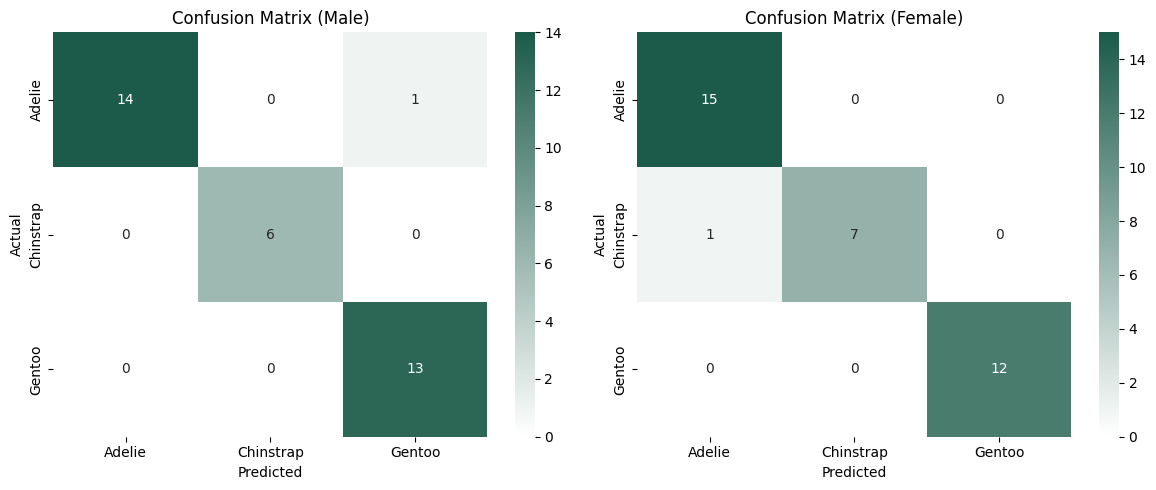

In [13]:
# Confusion matrix for subgroup - sex

# Get unique sexes
sexes = ["Male", "Female"]

# Prepare figure with 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Class labels (ensure consistent ordering)
labels = sorted(df_test["y_true"].unique())

# Loop through each sex and plot
for i, sex in enumerate(sexes):
    subset = df_test[df_test["sex"] == sex]
    cm = confusion_matrix(subset["y_true"], subset["y_pred"])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=custom_cmap,
        xticklabels=labels,
        yticklabels=labels,
        ax=axes[i]
    )
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].set_title(f"Confusion Matrix ({sex})")

plt.tight_layout()
plt.show()

**Big Picture:**
Reflecting on our medical diagnosis scenario, what do these subgroup analyses reveal about the model's accuracy for each specific disease?

**Critical Analysis:**

1. Trust & Reliability: If you were targeting the disease represented by the Gentoo subgroup, would you trust this model for human diagnosis?

1. The Problem of Scale: While this specific model only misidentified one penguin, how would that error rate scale across a population of 500, 1000, 10,000 patients?

1. Ethical Thresholds: In the context of human health, is a "small" error rate acceptable? At what point does a statistical discrepancy become a systemic failure?

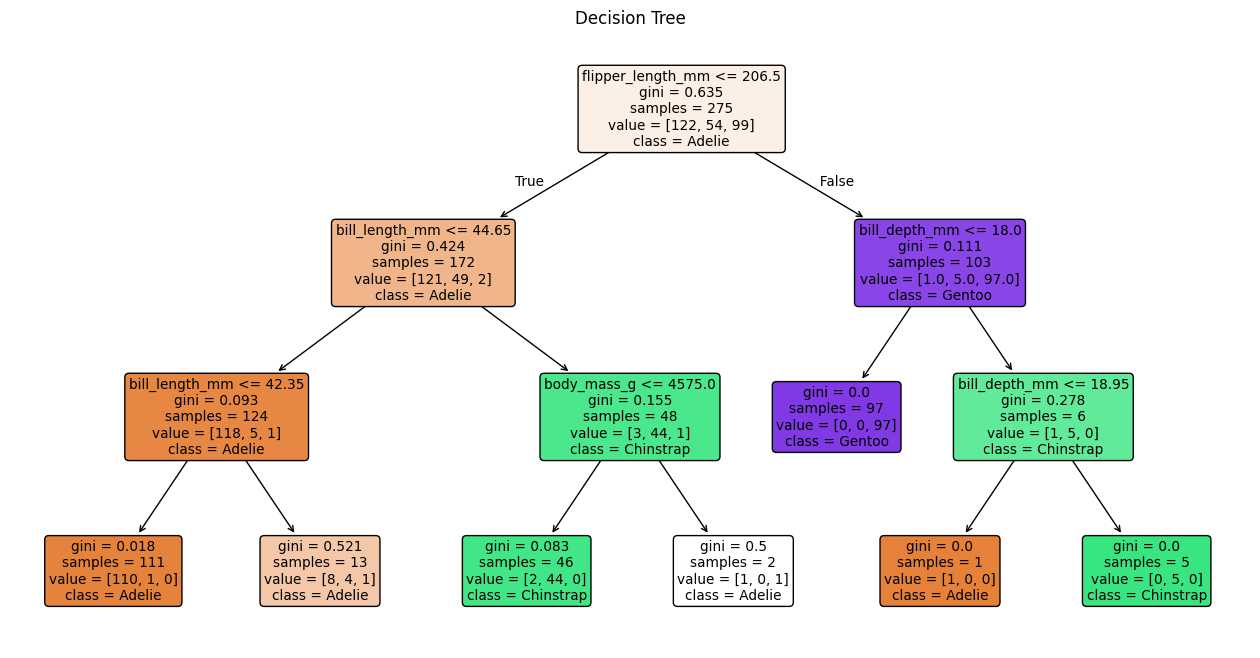

In [14]:
plt.figure(figsize=(16, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True
)

plt.title("Decision Tree")
plt.show()

**Consider:**
When using a classifier like Decision Tree, it can be helpful to look at how the model made its classification decisions. This shows you the weight each feature has in the decision making for the model.

# Model Datasheet

Further resources on datasheets, with published examples, can be found here: https://www.sciencedirect.com/topics/engineering/datasheet. The following example provides a simplified template of a datasheet for the Penguins dataset.

## Dataset
- Name: Palmer Penguins Dataset
- Source: seaborn (sns.load_dataset("penguins"))
- Size: ~333 samples after dropping missing values
- Features:
    Numeric: bill length, bill depth, flipper length, body mass
    categorical: sex
- Target: Multiclass classification (Adelie, Chinstrap, Gentoo)

## Preprocessing
- Mean imputation used for missing numeric values
- Dropped missing categorical values
- One-hot encoded categorical feature:
    -sex - binary indicator
 - No feature scaling applied (not required for decision trees)

## Model
- Type: Decision Tree Classifier
- Library: scikit-learn
- Hyperparameters:
  - max_depth = 3
  - random_state = 42

## Evaluation
### Overall Metrics
- Accuracy: 0.94
- Precision: 0.93
- Recall: 0.94

### Subgroup Metrics
| Subgroup      | Accuracy | Count |
|---------------|----------|-------|
| Male          | .966     | 29    |
| Female        | .921     | 38    |

## Ethical Considerations
- Sex is a real demographic attribute
- Model performance differences across sex groups may indicate:
    - Data imbalance
    - Measurement bias
    - Model reliance on correlated physical features
- Even though this dataset is biological (penguins), the same workflow applies to human-centered ML:
    - Always evaluate subgroup performance
    - Avoid relying on proxy variables unintentionally

## Limitations
- Small dataset
- Missing numeric values imputed (may introduce bias)
- Missing categroical values removed (may introduce bias)
- Single train/test split (no cross-validation)
- Limited subgroup analysis (only sex considered)
- Decision tree may overfit even with depth constraint

## Reflection

- What changes when the subgroup variable is socially consequential?
- Why do documentation and subgroup metrics matter more in human settings?